
# Drell--Yan angular coefficients with photon--$Z'$ interference

This notebook is a compact, editable version of the Drell--Yan calculation requested in the supervisor's email.

The task is:

1. Load real ATLAS/HEPData points for the angular coefficients $A_i$.
2. Compute the theoretical prediction for $A_0$, $A_1$ and $A_2$ using the full numerical convolution of Eq. (37), with no small-$Q_T$ expansion.
3. Compare the photon-only prediction with a photon plus photon--$Z'$ interference prediction.
4. Produce only the plots needed for this task.

The implemented amplitude-level approximation is

$$
|\mathcal M|^2
\simeq
|\mathcal M_\gamma|^2
+
2\,\mathrm{Re}\!\left(
\mathcal M_\gamma \mathcal M_{Z'}^\ast
\right).
$$

The pure quadratic term

$$
|\mathcal M_{Z'}|^2
$$

is intentionally not included, following the email instruction.



## How to use this notebook

Only edit the next cell, titled **EDIT HERE**.

Everything that is meant to be modified is collected there:

- the HEPData folder,
- the PDF set,
- the collider energy,
- the dilepton invariant mass,
- the $Q_T$ grid,
- the rapidity bins,
- the $Z'$ benchmark,
- plot and output options.

After changing that cell, run the notebook from top to bottom.


In [1]:

# ============================================================
# EDIT HERE: all user-modifiable inputs are in this cell
# ============================================================
# You should normally only modify this cell.
# The rest of the notebook implements the calculation.

from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad, IntegrationWarning
warnings.filterwarnings("ignore", category=IntegrationWarning)

import lhapdf

# ------------------------------------------------------------
# 1. Input data and PDFs
# ------------------------------------------------------------
# Folder containing the HEPData CSV tables downloaded from ATLAS.
DATA_DIR = Path("/home/addles/Docotorado/Jilberto/Znormal/REGAtables")

# LHAPDF set and member.
# The original paper used CT18NLO in some plots, while your code has used cteq61.
# Keep the one you have installed unless your supervisor asks for another PDF set.
PDF_SET = "cteq61"
PDF_MEMBER = 0

# Optional fallback for a local LHAPDF installation.
# Leave as None if your environment already finds LHAPDF correctly.
LOCAL_LHAPDF_DATA_PATH = Path("~/lhapdf6/share/LHAPDF").expanduser()

# ------------------------------------------------------------
# 2. Drell--Yan kinematics
# ------------------------------------------------------------
# Proton-proton center-of-mass energy in GeV.
sqrt_s = 8000.0

# Dilepton invariant mass in GeV.
# For the ATLAS Z-window comparison, Q is typically around 80--100 GeV.
Q = 100.0

# Transverse-momentum grid for the theoretical curves.
QT_MIN = 15.0
QT_MAX = 120.0
N_QT_POINTS = 15
QT_GRID = np.linspace(QT_MIN, QT_MAX, N_QT_POINTS)

# Number of points used to integrate over each rapidity interval.
# Increase for smoother numerical integration; decrease if the notebook is slow.
N_Y_GRID = 9

# HEPData regularisation choice.
# Usual options in the ATLAS tables are "regularised" and "unregularised".
REGULARISATION = "regularised"

# ------------------------------------------------------------
# 3. Angular-coefficient comparison setup
# ------------------------------------------------------------
# These are the rapidity bins used in the paper/ATLAS comparison for A0, A1 and A2.
# Each interval appears twice because the theory is integrated over +|y| and -|y|.
COMPARISON_CONFIG = {
    "A0": {
        "data_ybin": "2<|yZ|<3.5",
        "intervals": [(2.0, 3.5), (-3.5, -2.0)],
    },
    "A1": {
        "data_ybin": "1<|yZ|<2",
        "intervals": [(1.0, 2.0), (-2.0, -1.0)],
    },
    "A2": {
        "data_ybin": "2<|yZ|<3.5",
        "intervals": [(2.0, 3.5), (-3.5, -2.0)],
    },
}

# ------------------------------------------------------------
# 4. Z' benchmark selection
# ------------------------------------------------------------
# IMPORTANT:
# The supervisor's email did not provide numerical values for M_Zp, Gamma_Zp,
# or the Z' couplings. The values below are benchmarks only.
#
# If gV_u == gV_d, the Z' may mostly rescale all W_i by the same factor.
# Since A_i are ratios, that common factor can cancel and the photon-only
# and interference curves may become almost identical.
#
# To test that the interference is active, choose a non-universal benchmark
# with gV_u != gV_d.

ZPRIME_BENCHMARKS = {
    # Useful for code testing: should produce a visible nonzero Delta A_i.
    "illustrative_nonuniversal_visible": {
        "label": "illustrative_nonuniversal_visible",
        "M": 250.0,       # GeV
        "Gamma": 10.0,    # GeV
        "gV_l": 0.50,
        "gV_u": 0.80,
        "gV_d": -0.30,
    },

    # Useful to understand why curves can overlap: universal couplings tend to cancel in A_i.
    "heavy_universal_almost_cancels": {
        "label": "heavy_universal_almost_cancels",
        "M": 1000.0,
        "Gamma": 30.0,
        "gV_l": 0.10,
        "gV_u": 0.10,
        "gV_d": 0.10,
    },

    # A heavier but non-universal example.
    "heavy_nonuniversal_test": {
        "label": "heavy_nonuniversal_test",
        "M": 1000.0,
        "Gamma": 30.0,
        "gV_l": 0.30,
        "gV_u": 0.60,
        "gV_d": -0.20,
    },

    # Edit this block freely if you want your own benchmark.
    "custom": {
        "label": "custom",
        "M": 500.0,
        "Gamma": 20.0,
        "gV_l": 0.20,
        "gV_u": 0.30,
        "gV_d": -0.10,
    },
}

# Choose one default benchmark. This is kept for backward compatibility with the single-benchmark cells.
ZPRIME_BENCHMARK_NAME = "illustrative_nonuniversal_visible"
ZPRIME = ZPRIME_BENCHMARKS[ZPRIME_BENCHMARK_NAME].copy()

# ------------------------------------------------------------
# 5. Plot and output options
# ------------------------------------------------------------
MODELS = {
    "gamma": r"$\gamma$ only",
    "gamma_plus_Zp": r"$\gamma + \gamma Z'$ benchmark",
}

PLOT_DATA_COMPARISON = True
PLOT_ZP_SHIFT = True
SAVE_FIGURES = True
OUTDIR = Path("DY_Zprime_outputs")
OUTDIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 6. Print setup summary
# ------------------------------------------------------------
print("Analysis configured")
print("  DATA_DIR       =", DATA_DIR)
print("  PDF_SET        =", PDF_SET)
print("  sqrt(s)        =", sqrt_s, "GeV")
print("  Q              =", Q, "GeV")
print("  QT grid        =", QT_GRID[0], "to", QT_GRID[-1], "GeV with", len(QT_GRID), "points")
print("  N_Y_GRID       =", N_Y_GRID)
print("  regularisation =", REGULARISATION)
print("  default Z' benchmark =", ZPRIME)
print("  multi-Z' benchmark selection is defined near the final execution cell")


Analysis configured
  DATA_DIR       = /home/addles/Docotorado/Jilberto/Znormal/REGAtables
  PDF_SET        = cteq61
  sqrt(s)        = 8000.0 GeV
  Q              = 100.0 GeV
  QT grid        = 15.0 to 120.0 GeV with 15 points
  N_Y_GRID       = 9
  regularisation = regularised
  default Z' benchmark = {'label': 'illustrative_nonuniversal_visible', 'M': 250.0, 'Gamma': 10.0, 'gV_l': 0.5, 'gV_u': 0.8, 'gV_d': -0.3}
  multi-Z' benchmark selection is defined near the final execution cell



## Physics map of the calculation

The hadronic structure functions are evaluated schematically as

$$
W_i
=
\sum_{a,b}
\int dz_1\,dz_2\;
\widetilde w_i^{ab}(z_1,z_2,\rho^2)
\,
f_{a/h_1}\!\left(\frac{x_1}{z_1},\mu\right)
\,
f_{b/h_2}\!\left(\frac{x_2}{z_2},\mu\right)
\,
\delta(\text{phase space})
\times g_{\mathrm{EW}}.
$$

The pieces are:

- $\widetilde w_i^{ab}$: the perturbative partonic QCD kernel.
- $f_{a/h_1}$ and $f_{b/h_2}$: proton PDFs from LHAPDF.
- $\delta(\text{phase space})$: the one-parton recoil constraint.
- $g_{\mathrm{EW}}$: the electroweak weight.

The $Z'$ affects only the electroweak weight in this simplified implementation. The QCD kernels and the PDF convolution are unchanged.



## Load LHAPDF and HEPData tables

LHAPDF provides the proton PDFs

$$
f_i(x,\mu),
$$

where $x$ is the parton momentum fraction and $\mu$ is the factorization scale.

The HEPData CSV files provide experimental values of

$$
A_i(Q_T)
$$

with uncertainties.

This block standardizes every CSV table to the same columns:

```text
QT, QT_low, QT_high, Ai, err_plus, err_minus
```


In [2]:

# ============================================================
# 1. Load LHAPDF and HEPData
# ============================================================
# This cell loads PDFs and experimental angular-coefficient data.
# It should not need editing if the configuration cell is correct.

# LHAPDF normally finds the PDF sets through LHAPDF_DATA_PATH.
# The optional local fallback is defined in the editable configuration cell.
pdf_dir = LOCAL_LHAPDF_DATA_PATH
if "LHAPDF_DATA_PATH" not in os.environ and pdf_dir is not None and Path(pdf_dir).exists():
    os.environ["LHAPDF_DATA_PATH"] = str(pdf_dir)

try:
    pdf = lhapdf.mkPDF(PDF_SET, PDF_MEMBER)
except Exception as exc:
    raise RuntimeError(
        f"Could not load PDF set '{PDF_SET}'.\n"
        f"Check that it is installed and that LHAPDF_DATA_PATH is correct.\n"
        f"Current LHAPDF_DATA_PATH: {os.environ.get('LHAPDF_DATA_PATH')}"
    ) from exc

print("LHAPDF version:", lhapdf.version())
print("Loaded PDF set:", PDF_SET)


def read_hepdata_csv(file_path):
    """Read one HEPData CSV table and standardize the useful columns."""
    file_path = Path(file_path)
    metadata = {}
    header_line = None

    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        stripped = line.strip()

        if stripped.startswith("#:"):
            key_value = stripped[2:].strip()
            if ":" in key_value:
                key, value = key_value.split(":", 1)
                metadata[key.strip()] = value.strip()

        if stripped and not stripped.startswith("#"):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"No data header found in {file_path}")

    df = pd.read_csv(file_path, skiprows=header_line)
    description = metadata.get("description", "")

    coeff_match = re.search(r"\bA[0-7]\b", description)
    coefficient = coeff_match.group(0) if coeff_match else None

    ybin = None
    for line in lines:
        if line.startswith("#: Y BIN"):
            parts = line.strip().split(",,,")
            if len(parts) > 1:
                ybin = parts[1].strip()
            break

    desc_lower = description.lower()
    if "unregularised" in desc_lower or "unregularized" in desc_lower:
        regularisation = "unregularised"
    elif "regularised" in desc_lower or "regularized" in desc_lower:
        regularisation = "regularised"
    else:
        regularisation = "unknown"

    observable_cols = [c for c in df.columns if re.fullmatch(r"A[0-7]", c)]
    if not observable_cols:
        raise ValueError(f"No A_i column found in {file_path.name}")
    observable_col = observable_cols[0]

    out = pd.DataFrame()
    out["QT"] = df["PT [GEV]"]
    out["QT_low"] = df["PT [GEV] LOW"]
    out["QT_high"] = df["PT [GEV] HIGH"]
    out["Ai"] = df[observable_col]

    out["stat_plus"] = df.get("stat +", np.nan)
    out["stat_minus"] = df.get("stat -", np.nan)

    sys_plus_col = next((c for c in df.columns if "sys" in c and c.endswith("+") and "reg_bias" not in c), None)
    sys_minus_col = next((c for c in df.columns if "sys" in c and c.endswith("-") and "reg_bias" not in c), None)
    reg_plus_col = next((c for c in df.columns if "reg_bias" in c and c.endswith("+")), None)
    reg_minus_col = next((c for c in df.columns if "reg_bias" in c and c.endswith("-")), None)

    out["sys_plus"] = df[sys_plus_col] if sys_plus_col else 0.0
    out["sys_minus"] = df[sys_minus_col] if sys_minus_col else 0.0
    out["reg_bias_plus"] = df[reg_plus_col] if reg_plus_col else 0.0
    out["reg_bias_minus"] = df[reg_minus_col] if reg_minus_col else 0.0

    out["err_plus"] = np.sqrt(out["stat_plus"]**2 + out["sys_plus"]**2 + out["reg_bias_plus"]**2)
    out["err_minus"] = np.sqrt(out["stat_minus"].abs()**2 + out["sys_minus"].abs()**2 + out["reg_bias_minus"].abs()**2)

    info = {
        "file": file_path.name,
        "coefficient": coefficient,
        "ybin": ybin,
        "regularisation": regularisation,
        "description": description,
    }
    return info, out


def load_hepdata_tables(data_dir):
    """Load all CSV tables into a dictionary keyed by (A_i, ybin, regularisation)."""
    data_dir = Path(data_dir)
    if not data_dir.exists():
        print(f"Warning: DATA_DIR does not exist: {data_dir}")
        return {}

    data_by_key = {}
    for csv_file in sorted(data_dir.glob("*.csv")):
        try:
            info, df = read_hepdata_csv(csv_file)
            key = (info["coefficient"], info["ybin"], info["regularisation"])
            data_by_key[key] = df
        except Exception as exc:
            print(f"Skipping {csv_file.name}: {exc}")

    return data_by_key


def normalize_label(text):
    return (
        str(text)
        .replace(" ", "")
        .replace("\\", "")
        .replace("{", "")
        .replace("}", "")
        .lower()
    )


def find_hepdata_dataset(data_by_key, coeff, ybin, regularisation):
    """Find a HEPData table using exact matching first, normalized matching second."""
    exact = (coeff, ybin, regularisation)
    if exact in data_by_key:
        return exact, data_by_key[exact]

    target_y = normalize_label(ybin)
    target_reg = normalize_label(regularisation)

    for key, df in data_by_key.items():
        k_coeff, k_ybin, k_reg = key
        if k_coeff != coeff:
            continue
        if normalize_label(k_ybin) == target_y and normalize_label(k_reg) == target_reg:
            return key, df

    return None, None


data_by_key = load_hepdata_tables(DATA_DIR)
print(f"Loaded {len(data_by_key)} HEPData tables")
for key in sorted(data_by_key):
    print(" ", key)


LHAPDF 6.5.5 loading /home/addles/lhapdf6/share/LHAPDF/cteq61/cteq61_0000.dat
cteq61 PDF set, member #0, version 1; LHAPDF ID = 10150
LHAPDF version: 6.5.5
Loaded PDF set: cteq61
Loaded 5 HEPData tables
  ('A0', '2<|yZ|<3.5', 'regularised')
  ('A1', '1<|yZ|<2', 'regularised')
  ('A2', '2<|yZ|<3.5', 'regularised')
  ('A3', '2<|yZ|<3.5', 'regularised')
  ('A4', '2<|yZ|<3.5', 'regularised')



## Kinematics, phase-space delta, kernels and $Z'$ weights

For each value of $Q_T$ and rapidity $y$, the code defines

$$
\rho^2=\frac{Q_T^2}{Q^2},
$$

$$
\mu=\sqrt{Q^2+Q_T^2},
$$

and

$$
x_1=e^y\frac{\sqrt{Q^2+Q_T^2}}{\sqrt{s}},
$$

$$
x_2=e^{-y}\frac{\sqrt{Q^2+Q_T^2}}{\sqrt{s}}.
$$

The phase-space delta imposes

$$
(1-z_1)(1-z_2)
-
\frac{\rho^2 z_1z_2}{1+\rho^2}
=
0.
$$

Solving this constraint for $z_2$ gives

$$
z_2=\sigma(z_1)
=
1-
\frac{\rho^2 z_1}{1+\rho^2-z_1}.
$$

The delta therefore reduces the original two-dimensional convolution to a one-dimensional numerical integral in $z_1$.


In [3]:

# ============================================================
# 2. Physics functions: kinematics, kernels and electroweak weights
# ============================================================
# This is the core physics block.
# It defines:
#   - quark flavors and color factors;
#   - PDFs f_i(x, mu);
#   - Drell--Yan kinematics x1, x2, rho^2 and mu;
#   - the phase-space delta solution used in Eq. (37);
#   - the real part of a Breit-Wigner propagator for the Z';
#   - the partonic kernels for WT, WL, W_DeltaDelta and W_Delta.

QUARKS = [1, 2, 3, 4, 5]  # d, u, s, c, b in PDG/LHAPDF notation
C_QQBAR = 4.0/9.0
C_QG = 1.0/6.0


def electric_charge(q):
    """Electric charge of a quark flavor in units of |e|."""
    if abs(q) in [2, 4]:
        return 2.0/3.0
    if abs(q) in [1, 3, 5]:
        return -1.0/3.0
    raise ValueError(f"Unknown quark flavor: {q}")


def f_pdf(pid, x, mu):
    """Return f_i(x, mu). LHAPDF returns x*f_i(x, mu), so divide by x."""
    if x <= 0.0 or x >= 1.0:
        return 0.0
    return pdf.xfxQ(pid, x, mu)/x


def kinematics(QT, y_value):
    """Return x1, x2, rho^2 and mu for fixed QT and rapidity y."""
    rho2 = (QT/Q)**2
    mu = np.sqrt(Q**2 + QT**2)
    x1 = np.exp(y_value)*mu/sqrt_s
    x2 = np.exp(-y_value)*mu/sqrt_s
    return x1, x2, rho2, mu


def sigma_z2(z1, rho2):
    """Solution z2 = sigma(z1) of the phase-space delta constraint."""
    return 1.0 - rho2*z1/(1.0 + rho2 - z1)


def jacobian_delta(z1, rho2):
    """Jacobian produced when the phase-space delta removes the z2 integral."""
    return (1.0 + rho2)/(1.0 + rho2 - z1)


def z1_limits(x1, x2, rho2):
    """Integration limits for the remaining z1 integral."""
    return x1, sigma_z2(x2, rho2)


def Re_D_breit_wigner(Q_value, M, Gamma):
    """
    Real part of the dimensionless Breit-Wigner factor.

    This is the piece that enters the photon--Z' interference term:

        Re[D] = (M^2 - Q^2) Q^2 / [(M^2 - Q^2)^2 + M^2 Gamma^2].

    If Re[D] changes sign, the interference can also change sign.
    """
    Q2 = Q_value**2
    return ((M**2 - Q2)*Q2)/((M**2 - Q2)**2 + M**2*Gamma**2)


def zprime_coupling_quark(q, zp):
    """Return the vector Z' coupling for the requested quark flavor."""
    if abs(q) in [2, 4]:
        return zp["gV_u"]
    if abs(q) in [1, 3, 5]:
        return zp["gV_d"]
    raise ValueError(f"Unknown quark flavor: {q}")


def zprime_signature(zp):
    """Hashable signature for cache keys. This allows changing Z' inputs safely."""
    signature = []
    for key in sorted(zp):
        value = zp[key]
        if isinstance(value, (int, float, np.floating)):
            signature.append((key, round(float(value), 12)))
        else:
            signature.append((key, str(value)))
    return tuple(signature)


def gEW_gamma_Zp(q, Q_value, model, zp):
    """
    Electroweak weight multiplying the QCD kernel.

    This implements the structure requested in the supervisor's email.
    The QCD part is unchanged; only the electroweak flavor weight changes.

    model = "gamma":
        |M_gamma|^2 -> gEW = 1

    model = "gamma_plus_Zp":
        |M_gamma|^2 + 2 Re(M_gamma M_Zp*)
        -> gEW = 1 + 2 gV_q' gV_l' Re[D_Zp]

    The pure |M_Zp|^2 term is intentionally omitted.
    """
    if model == "gamma":
        return 1.0

    if model == "gamma_plus_Zp":
        gV_q = zprime_coupling_quark(q, zp)
        gV_l = zp["gV_l"]
        re_d = Re_D_breit_wigner(Q_value, zp["M"], zp["Gamma"])
        return 1.0 + 2.0*gV_q*gV_l*re_d

    raise ValueError(f"Unknown model: {model}")


def zprime_weight_for_flavor(q, zp, Q_value=Q):
    """Return the electroweak weight for one quark flavor in the gamma+gammaZ' model."""
    return gEW_gamma_Zp(q, Q_value, "gamma_plus_Zp", zp)


def print_zprime_diagnostic(zp, Q_value=Q):
    """
    Print a short diagnostic for the chosen Z' benchmark.

    This explains whether the benchmark can visibly modify A_i, or whether it
    mostly cancels as an overall normalization in angular-coefficient ratios.
    """
    re_d = Re_D_breit_wigner(Q_value, zp["M"], zp["Gamma"])
    w_u = zprime_weight_for_flavor(2, zp, Q_value)
    w_d = zprime_weight_for_flavor(1, zp, Q_value)

    print("Z' benchmark diagnostic")
    print("  label      =", zp.get("label", "unlabeled"))
    print(f"  M_Zp       = {zp['M']:.6g} GeV")
    print(f"  Gamma_Zp   = {zp['Gamma']:.6g} GeV")
    print(f"  gV_l       = {zp['gV_l']:.6g}")
    print(f"  gV_u       = {zp['gV_u']:.6g}")
    print(f"  gV_d       = {zp['gV_d']:.6g}")
    print(f"  Re[D_Zp]   = {re_d:.6e} at Q = {Q_value:.3g} GeV")
    print(f"  EW weight for u/c quarks = {w_u:.8f}")
    print(f"  EW weight for d/s/b quarks = {w_d:.8f}")
    print(f"  flavor non-universality |w_u-w_d| = {abs(w_u-w_d):.6e}")

    if abs(w_u - w_d) < 1e-8:
        print("  WARNING: up- and down-type quarks receive the same weight.")
        print("           A0, A1 and A2 may be identical to photon-only because this factor cancels in the ratios.")
    elif max(abs(w_u-1.0), abs(w_d-1.0)) < 1e-4:
        print("  WARNING: the interference weight is very close to 1.")
        print("           The Z' shift may be too small to see on the main plot; inspect Delta A_i.")
    else:
        print("  This benchmark should produce nonzero flavor reweighting.")
        print("  Any visible change in A_i comes from changing the relative u-type and d-type contributions.")


def coupling_factor(channel, q, Q_value, mu, model, zp):
    """Overall coupling factor multiplying each partonic kernel."""
    eq2 = electric_charge(q)**2
    alpha_s = pdf.alphasQ(mu)
    color = C_QQBAR if channel == "qqbar" else C_QG
    return 8.0*np.pi**2 * alpha_s * color * eq2 * gEW_gamma_Zp(q, Q_value, model, zp)


def kernel_qqbar(structure, z1, z2, rho2):
    """Partonic q qbar kernels for WT, WL, W_DeltaDelta and W_Delta."""
    rho = np.sqrt(rho2)
    base = (z1**2 + z2**2)/(z1*z2)

    if structure == "T":
        return (1.0/rho2)*(1.0 + rho2/2.0)*base
    if structure == "L":
        return base
    if structure == "DD":
        return 0.5*base
    if structure == "Delta":
        return (1.0/rho)*(z1**2 - z2**2)/(z1*z2)

    raise ValueError(f"Unknown structure: {structure}")


def kernel_qg_direct(structure, z1, z2, rho2):
    """Partonic qg kernels for WT, WL, W_DeltaDelta and W_Delta."""
    rho = np.sqrt(rho2)
    common = (1.0 - z2)/(z1*z2)

    if structure == "T":
        bracket = (
            z2**2
            + (1.0 - z1*z2)**2
            + rho2*(1.0 - z1**2/2.0 - z1*z2*(z1 + z2))
        )
        return (1.0/rho2)*common*bracket

    if structure == "L":
        return common*(z2**2 + (z1 + z2)**2)
    if structure == "DD":
        return 0.5*common*(z2**2 + (z1 + z2)**2)
    if structure == "Delta":
        return (1.0/rho)*common*(z1**2 - 2.0*z2**2)

    raise ValueError(f"Unknown structure: {structure}")


def kernel_gq_crossed(structure, z1, z2, rho2):
    """Crossed gq kernel. Delta is antisymmetric; T, L and DD are symmetric."""
    if structure == "Delta":
        return -kernel_qg_direct(structure, z2, z1, rho2)
    return kernel_qg_direct(structure, z2, z1, rho2)



## Numerical convolution and construction of $A_0$, $A_1$ and $A_2$

The calculation includes the quark-antiquark channel

$$
q\bar q\to \gamma^*/Z' + g,
$$

and the Compton channels

$$
qg\to \gamma^*/Z' + q,
$$

$$
gq\to \gamma^*/Z' + q.
$$

For each $Q_T$, rapidity interval and electroweak model, the code computes

$$
W_T,
\qquad
W_L,
\qquad
W_{\Delta\Delta},
\qquad
W_\Delta.
$$

Then it constructs

$$
A_0=
\frac{2W_L}{2W_T+W_L},
$$

$$
A_1=
\frac{2W_\Delta}{2W_T+W_L},
$$

$$
A_2=
\frac{4W_{\Delta\Delta}}{2W_T+W_L}.
$$


In [4]:

# ============================================================
# 3. Numerical convolution and angular coefficients
# ============================================================
# This cell evaluates Eq. (37) numerically.
# The phase-space delta removes one integration and leaves a 1D integral in z1.
# The W_i are integrated over the selected rapidity bins and then combined into:
#   A0 = 2 WL / (2 WT + WL)
#   A1 = 2 WDelta / (2 WT + WL)
#   A2 = 4 WDeltaDelta / (2 WT + WL)

# Cache repeated W_i(QT, y) evaluations.
# This speeds up the calculation because A0, A1 and A2 share the same denominator.
structure_cache = {}


def integrate_qqbar(structure, QT, y_value, model, zp):
    x1, x2, rho2, mu = kinematics(QT, y_value)
    zmin, zmax = z1_limits(x1, x2, rho2)
    if zmax <= zmin:
        return 0.0

    def integrand(z1):
        z2 = sigma_z2(z1, rho2)
        if not (x2 < z2 < 1.0):
            return 0.0

        xi1 = x1/z1
        xi2 = x2/z2
        if not (0.0 < xi1 < 1.0 and 0.0 < xi2 < 1.0):
            return 0.0

        J = jacobian_delta(z1, rho2)
        ker = kernel_qqbar(structure, z1, z2, rho2)

        total = 0.0
        for q in QUARKS:
            qbar = -q
            pdf_part = f_pdf(q, xi1, mu)*f_pdf(qbar, xi2, mu) + f_pdf(qbar, xi1, mu)*f_pdf(q, xi2, mu)
            total += coupling_factor("qqbar", q, Q, mu, model, zp)*pdf_part

        return J*ker*total

    value, _ = quad(integrand, zmin, zmax, epsabs=1e-6, epsrel=1e-4, limit=200)
    return value/(x1*x2)


def integrate_qg_plus_gq(structure, QT, y_value, model, zp):
    x1, x2, rho2, mu = kinematics(QT, y_value)
    zmin, zmax = z1_limits(x1, x2, rho2)
    if zmax <= zmin:
        return 0.0

    def integrand(z1):
        z2 = sigma_z2(z1, rho2)
        if not (x2 < z2 < 1.0):
            return 0.0

        xi1 = x1/z1
        xi2 = x2/z2
        if not (0.0 < xi1 < 1.0 and 0.0 < xi2 < 1.0):
            return 0.0

        J = jacobian_delta(z1, rho2)
        ker_qg = kernel_qg_direct(structure, z1, z2, rho2)
        ker_gq = kernel_gq_crossed(structure, z1, z2, rho2)

        g1 = f_pdf(21, xi1, mu)
        g2 = f_pdf(21, xi2, mu)

        total = 0.0
        for q in QUARKS:
            qbar = -q
            cf = coupling_factor("qg", q, Q, mu, model, zp)

            pdf_qg = (f_pdf(q, xi1, mu) + f_pdf(qbar, xi1, mu))*g2
            pdf_gq = g1*(f_pdf(q, xi2, mu) + f_pdf(qbar, xi2, mu))

            total += cf*(ker_qg*pdf_qg + ker_gq*pdf_gq)

        return J*total

    value, _ = quad(integrand, zmin, zmax, epsabs=1e-6, epsrel=1e-4, limit=200)
    return value/(x1*x2)


def structure_total(structure, QT, y_value, model, zp):
    key = (
        structure,
        round(float(QT), 8),
        round(float(y_value), 8),
        model,
        zprime_signature(zp),
    )
    if key not in structure_cache:
        structure_cache[key] = integrate_qqbar(structure, QT, y_value, model, zp) + integrate_qg_plus_gq(structure, QT, y_value, model, zp)
    return structure_cache[key]


def trapz_integral(x, y):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return np.trapz(y, x)


def A012_for_intervals(QT, intervals, model, zp, n_y=N_Y_GRID):
    num_A0 = 0.0
    num_A1 = 0.0
    num_A2 = 0.0
    den = 0.0

    for y_min, y_max in intervals:
        y_grid = np.linspace(y_min, y_max, n_y)

        WT = np.array([structure_total("T", QT, yv, model, zp) for yv in y_grid])
        WL = np.array([structure_total("L", QT, yv, model, zp) for yv in y_grid])
        WDD = np.array([structure_total("DD", QT, yv, model, zp) for yv in y_grid])
        WD = np.array([structure_total("Delta", QT, yv, model, zp) for yv in y_grid])

        den_vals = 2.0*WT + WL
        num_A0 += trapz_integral(y_grid, 2.0*WL)
        num_A1 += trapz_integral(y_grid, 2.0*WD)
        num_A2 += trapz_integral(y_grid, 4.0*WDD)
        den += trapz_integral(y_grid, den_vals)

    return {
        "A0": num_A0/den,
        "A1": num_A1/den,
        "A2": num_A2/den,
    }


def compute_theory_curves(qt_grid=QT_GRID, models=MODELS, zp=ZPRIME):
    """
    Calcula A0, A1 y A2 para todos los modelos pedidos.

    model='gamma'           : solo |M_gamma|^2.
    model='gamma_plus_Zp'   : |M_gamma|^2 + interferencia gamma-Z'.
    """
    results = {}

    # Group coefficients by identical rapidity intervals to avoid duplicate integrations.
    interval_groups = {}
    for coeff, cfg in COMPARISON_CONFIG.items():
        interval_key = tuple(cfg["intervals"])
        interval_groups.setdefault(interval_key, []).append(coeff)

    for model in models:
        print(f"\nComputing model: {model}")
        results[model] = {"QT": np.array(qt_grid, dtype=float)}
        for coeff in COMPARISON_CONFIG:
            results[model][coeff] = np.empty(len(qt_grid), dtype=float)

        for interval_key, coeffs in interval_groups.items():
            intervals = list(interval_key)
            print("  intervals:", intervals, "->", coeffs)

            for i, QT in enumerate(qt_grid):
                print(f"    QT {i+1:02d}/{len(qt_grid)} = {QT:.1f} GeV", end="\r")
                values = A012_for_intervals(QT, intervals, model, zp, n_y=N_Y_GRID)
                for coeff in coeffs:
                    results[model][coeff][i] = values[coeff]
            print()

    return results


## Select the $Z'$ benchmarks to process

Edit the list in the next cell whenever you want to compare a different set of $Z'$ hypotheses.

Each name must be one of the keys defined in `ZPRIME_BENCHMARKS` in the configuration cell above. The final execution cell will read this list and automatically compute/plot all selected cases.

Example:

```python
ZPRIME_BENCHMARK_NAMES_TO_PROCESS = [
    "custom",
    "heavy_nonuniversal_test",
]
```


In [5]:
# ============================================================
# EDIT HERE BEFORE RUNNING THE FINAL PLOTS
# ============================================================
# Choose as many Z' benchmarks as you want to process.
# Add or remove names from this list.
# Every name must be a key in ZPRIME_BENCHMARKS.

ZPRIME_BENCHMARK_NAMES_TO_PROCESS = [
    "illustrative_nonuniversal_visible",
    "heavy_universal_almost_cancels",
    "heavy_nonuniversal_test",
    "custom",
]

print("Benchmarks selected for the final comparison:")
for name in ZPRIME_BENCHMARK_NAMES_TO_PROCESS:
    if name not in ZPRIME_BENCHMARKS:
        print(f"  - {name}  <-- NOT FOUND")
    else:
        zp = ZPRIME_BENCHMARKS[name]
        print(
            f"  - {name}: "
            f"M={zp['M']} GeV, Gamma={zp['Gamma']} GeV, "
            f"gV_l={zp['gV_l']}, gV_u={zp['gV_u']}, gV_d={zp['gV_d']}"
        )


Benchmarks selected for the final comparison:
  - illustrative_nonuniversal_visible: M=250.0 GeV, Gamma=10.0 GeV, gV_l=0.5, gV_u=0.8, gV_d=-0.3
  - heavy_universal_almost_cancels: M=1000.0 GeV, Gamma=30.0 GeV, gV_l=0.1, gV_u=0.1, gV_d=0.1
  - heavy_nonuniversal_test: M=1000.0 GeV, Gamma=30.0 GeV, gV_l=0.3, gV_u=0.6, gV_d=-0.2
  - custom: M=500.0 GeV, Gamma=20.0 GeV, gV_l=0.2, gV_u=0.3, gV_d=-0.1



## Final result: individual benchmark comparison plots

This block uses the list

$$
\texttt{ZPRIME\_BENCHMARK\_NAMES\_TO\_PROCESS}
$$

defined in the previous cell.

The plotting strategy is now **individual**:

- one figure per selected $Z'$ benchmark;
- each figure compares data, photon-only theory, and that single $Z'$ interference benchmark;
- different $Z'$ benchmarks are not drawn on top of each other.

This makes the comparison easier to read when several benchmark points are tested.

The $x$-axis is set independently for each coefficient. This avoids the large $A_1$ bin range from stretching the $A_0$ and $A_2$ panels.


Selected Z' benchmarks:

--- illustrative_nonuniversal_visible ---
Z' benchmark diagnostic
  label      = illustrative_nonuniversal_visible
  M_Zp       = 250 GeV
  Gamma_Zp   = 10 GeV
  gV_l       = 0.5
  gV_u       = 0.8
  gV_d       = -0.3
  Re[D_Zp]   = 1.900452e-01 at Q = 100 GeV
  EW weight for u/c quarks = 1.15203620
  EW weight for d/s/b quarks = 0.94298643
  flavor non-universality |w_u-w_d| = 2.090498e-01
  This benchmark should produce nonzero flavor reweighting.
  Any visible change in A_i comes from changing the relative u-type and d-type contributions.

--- heavy_universal_almost_cancels ---
Z' benchmark diagnostic
  label      = heavy_universal_almost_cancels
  M_Zp       = 1000 GeV
  Gamma_Zp   = 30 GeV
  gV_l       = 0.1
  gV_u       = 0.1
  gV_d       = 0.1
  Re[D_Zp]   = 1.009174e-02 at Q = 100 GeV
  EW weight for u/c quarks = 1.00020183
  EW weight for d/s/b quarks = 1.00020183
  flavor non-universality |w_u-w_d| = 0.000000e+00
           A0, A1 and A2 may be identi

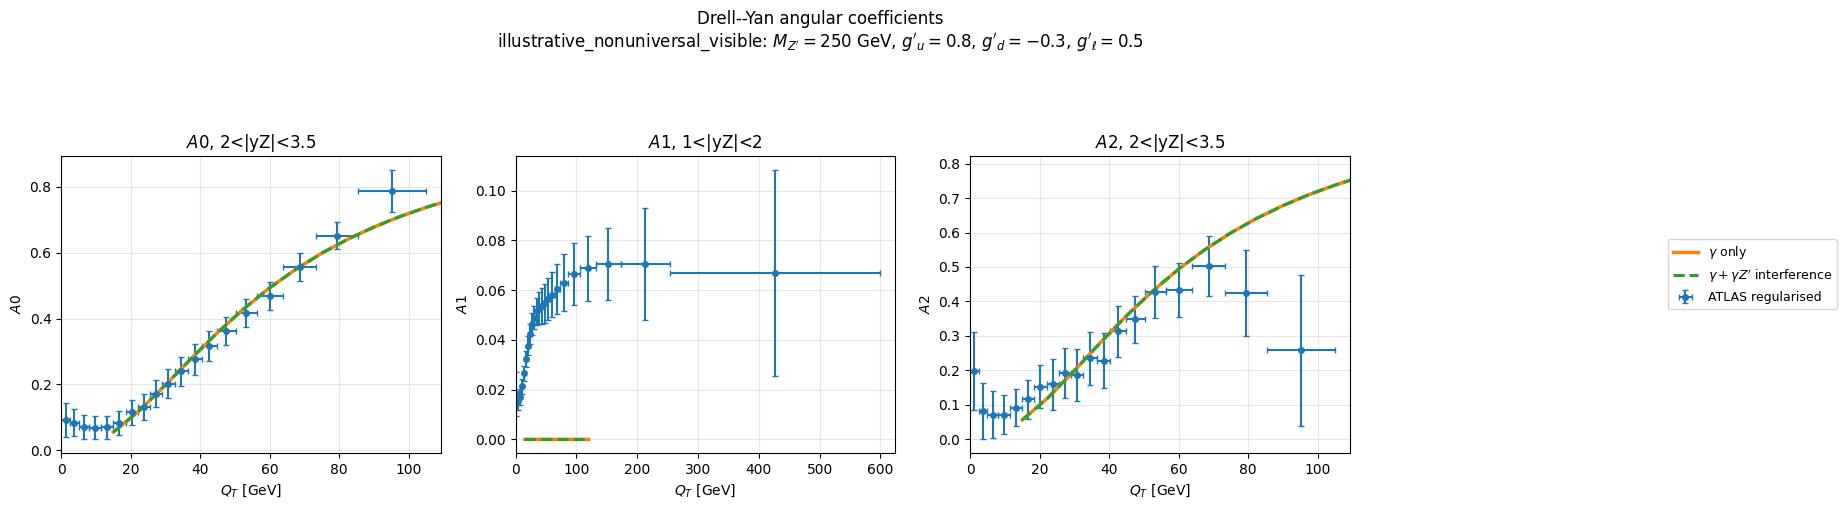

Saved: DY_Zprime_outputs/A012_comparison_heavy_universal_almost_cancels.png


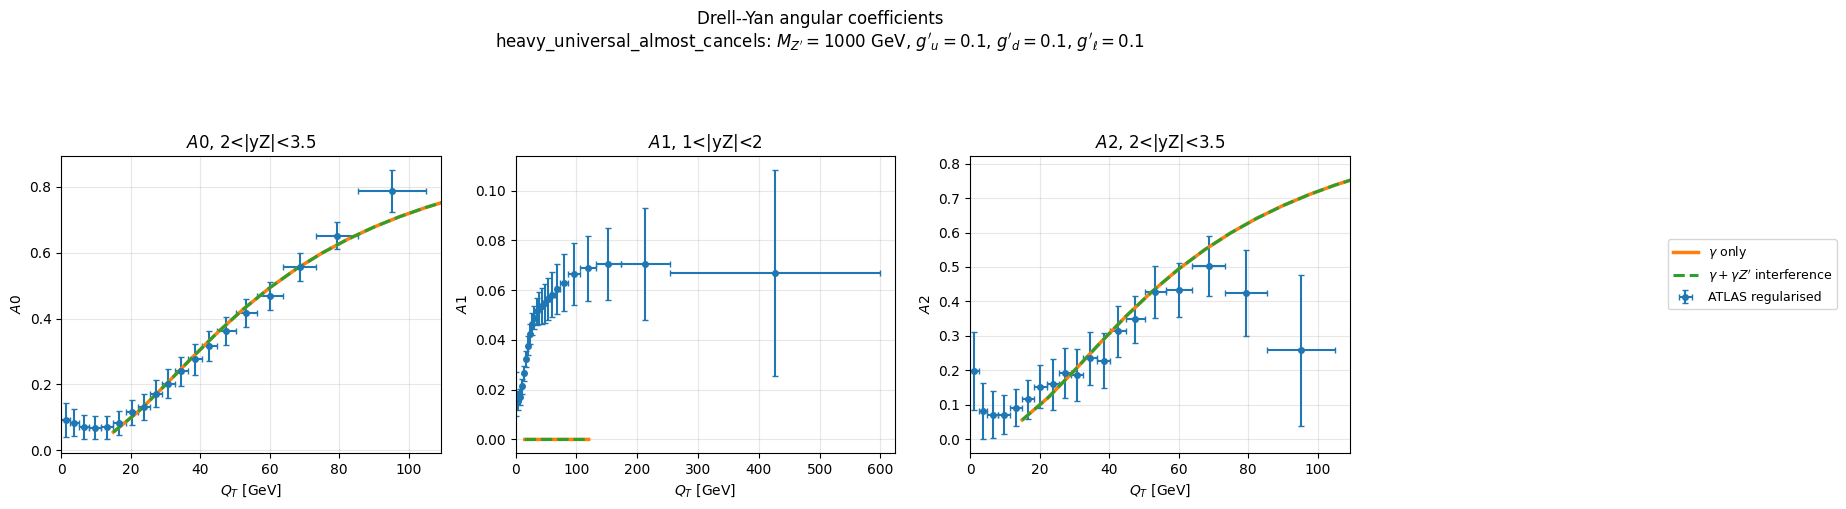

Saved: DY_Zprime_outputs/A012_comparison_heavy_nonuniversal_test.png


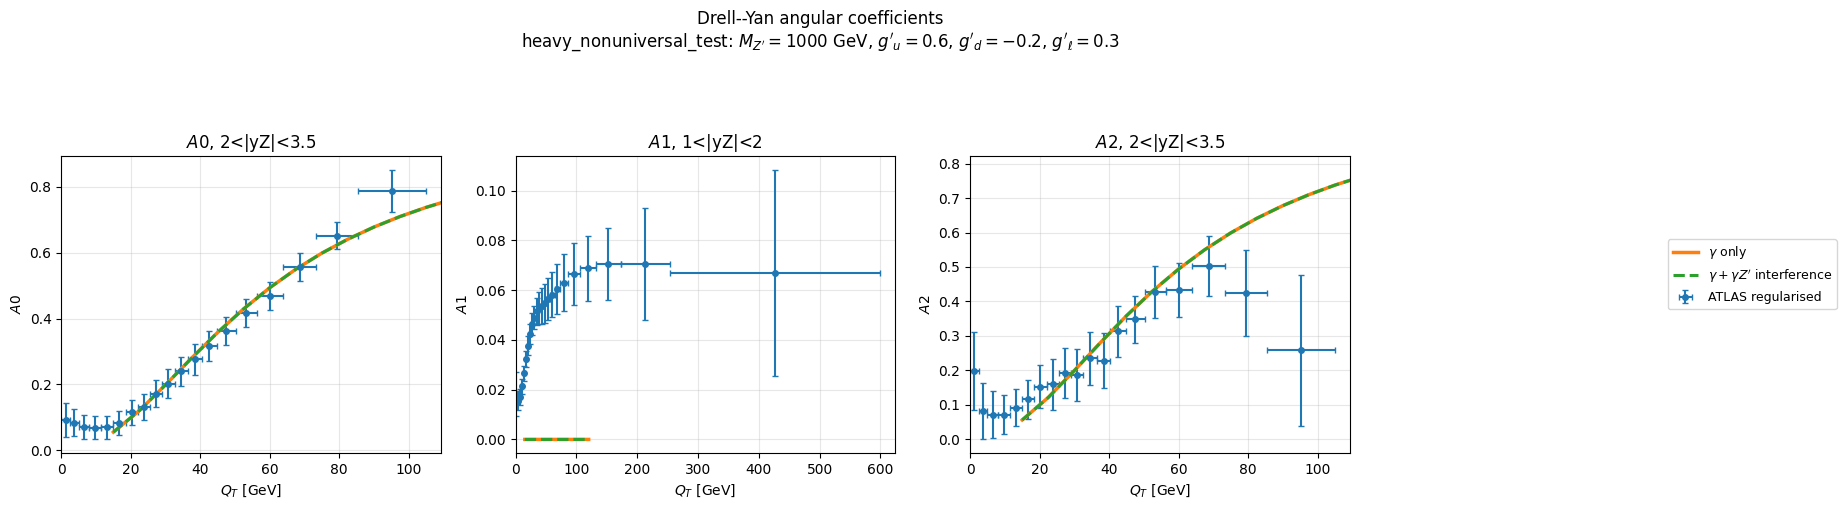

Saved: DY_Zprime_outputs/A012_comparison_custom.png


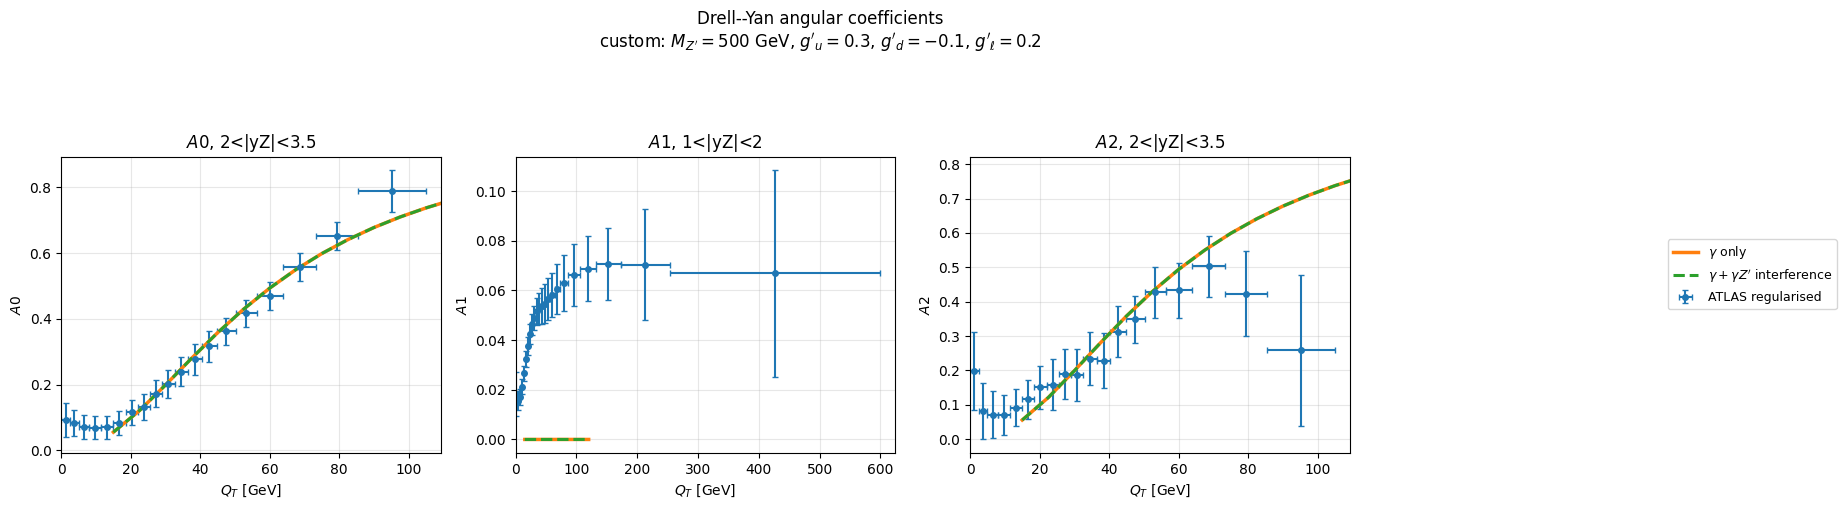

In [9]:

# ============================================================
# 4. Final execution: individual Z' benchmark comparisons
# ============================================================
# This cell:
#   1) validates the selected Z' benchmark names;
#   2) computes the photon-only curve once;
#   3) computes one gamma + gamma-Z' curve for each selected benchmark;
#   4) produces one independent comparison plot per benchmark.
#
# It does NOT overlay all Z' cases in the same plot.

# ------------------------------------------------------------
# 4.1 Validate the selected benchmark names
# ------------------------------------------------------------
missing = [name for name in ZPRIME_BENCHMARK_NAMES_TO_PROCESS if name not in ZPRIME_BENCHMARKS]

if missing:
    raise ValueError(
        "These names are not defined in ZPRIME_BENCHMARKS: "
        + ", ".join(missing)
        + "\nAvailable names are: "
        + ", ".join(ZPRIME_BENCHMARKS.keys())
    )

selected_zp_benchmarks = {
    name: ZPRIME_BENCHMARKS[name].copy()
    for name in ZPRIME_BENCHMARK_NAMES_TO_PROCESS
}

print("Selected Z' benchmarks:")
for name, zp in selected_zp_benchmarks.items():
    print("\n---", name, "---")
    print_zprime_diagnostic(zp)


# ------------------------------------------------------------
# 4.2 Compute photon-only once and all selected Z' curves
# ------------------------------------------------------------
def compute_selected_benchmark_theory(qt_grid=QT_GRID, selected_benchmarks=selected_zp_benchmarks):
    """
    Compute the photon-only reference curve once and one gamma+gammaZ' curve
    for each selected benchmark.

    Output structure:

        theory_by_scenario["gamma"]["A0"], theory_by_scenario["gamma"]["A1"], ...
        theory_by_scenario["Zp::<benchmark_name>"]["A0"], ...
    """
    theory_by_scenario = {}

    print("\nComputing photon-only reference curve")
    photon_result = compute_theory_curves(
        qt_grid=qt_grid,
        models=["gamma"],
        zp={
            "label": "photon_reference",
            "M": 1.0,
            "Gamma": 1.0,
            "gV_l": 0.0,
            "gV_u": 0.0,
            "gV_d": 0.0,
        },
    )
    theory_by_scenario["gamma"] = photon_result["gamma"]

    for name, zp in selected_benchmarks.items():
        print(f"\nComputing Z' benchmark: {name}")
        zp_result = compute_theory_curves(
            qt_grid=qt_grid,
            models=["gamma_plus_Zp"],
            zp=zp,
        )
        theory_by_scenario[f"Zp::{name}"] = zp_result["gamma_plus_Zp"]

    return theory_by_scenario


theory_by_scenario = compute_selected_benchmark_theory()


# ------------------------------------------------------------
# 4.3 Plot helpers
# ------------------------------------------------------------
def benchmark_label(name):
    """Short label used in plot titles and legends."""
    zp = ZPRIME_BENCHMARKS[name]
    return (
        rf"{name}: "
        rf"$M_{{Z'}}={zp['M']:.0f}$ GeV, "
        rf"$g'_u={zp['gV_u']:.2g}$, "
        rf"$g'_d={zp['gV_d']:.2g}$, "
        rf"$g'_\ell={zp['gV_l']:.2g}$"
    )


def get_data_x_limits(df_exp, fallback_qt_grid=QT_GRID):
    """
    Return coefficient-specific x-limits.

    The limits are based on the HEPData bin edges of the coefficient being plotted.
    This prevents the large A1 range from forcing A0 and A2 to use the same x-scale.
    """
    if df_exp is None or len(df_exp) == 0:
        return float(np.min(fallback_qt_grid)), float(np.max(fallback_qt_grid))

    x_low = float(np.nanmin(df_exp["QT_low"]))
    x_high = float(np.nanmax(df_exp["QT_high"]))

    if not np.isfinite(x_low) or not np.isfinite(x_high) or x_high <= x_low:
        return float(np.min(fallback_qt_grid)), float(np.max(fallback_qt_grid))

    margin = 0.04*(x_high - x_low)
    return max(0.0, x_low - margin), x_high + margin


def add_experimental_data(ax, coeff):
    """
    Add ATLAS/HEPData points for one coefficient and return the dataframe.

    The selected HEPData table is controlled by COMPARISON_CONFIG and REGULARISATION.
    """
    cfg = COMPARISON_CONFIG[coeff]
    key, df_exp = find_hepdata_dataset(
        data_by_key,
        coeff,
        cfg["data_ybin"],
        REGULARISATION,
    )

    if df_exp is None:
        ax.text(0.04, 0.94, "HEPData table not found", transform=ax.transAxes, va="top")
        return None

    xerr = [
        df_exp["QT"] - df_exp["QT_low"],
        df_exp["QT_high"] - df_exp["QT"],
    ]
    yerr = [
        df_exp["err_minus"],
        df_exp["err_plus"],
    ]

    ax.errorbar(
        df_exp["QT"],
        df_exp["Ai"],
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        ms=4,
        capsize=2,
        label=f"ATLAS {REGULARISATION}",
    )

    return df_exp


def plot_single_benchmark_comparison(benchmark_name, theory_by_scenario):
    """
    Produce one comparison figure for one Z' benchmark.

    Each figure contains three independent panels:
      - A0;
      - A1;
      - A2.

    Each panel shows:
      - ATLAS/HEPData points;
      - photon-only theory;
      - gamma + gamma-Z' interference for the chosen benchmark.
    """
    scenario_key = f"Zp::{benchmark_name}"
    if scenario_key not in theory_by_scenario:
        raise KeyError(f"Missing computed theory for {scenario_key}")

    photon = theory_by_scenario["gamma"]
    zp_curve = theory_by_scenario[scenario_key]

    # Do not use sharex=True here.
    # A1 has a much wider experimental QT bin than A0 and A2.
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

    for ax, coeff in zip(axes, ["A0", "A1", "A2"]):
        cfg = COMPARISON_CONFIG[coeff]
        df_exp = add_experimental_data(ax, coeff)

        ax.plot(
            photon["QT"],
            photon[coeff],
            linestyle="-",
            linewidth=2.5,
            label=r"$\gamma$ only",
        )
        ax.plot(
            zp_curve["QT"],
            zp_curve[coeff],
            linestyle="--",
            linewidth=2.2,
            label=r"$\gamma+\gamma Z'$ interference",
        )

        x_min, x_max = get_data_x_limits(df_exp)
        ax.set_xlim(x_min, x_max)

        ax.set_title(rf"${coeff}$, {cfg['data_ybin']}")
        ax.set_xlabel(r"$Q_T$ [GeV]")
        ax.set_ylabel(rf"${coeff}$")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)

    fig.suptitle(
        "Drell--Yan angular coefficients\n"
        + benchmark_label(benchmark_name),
        y=1.05,
    )

    plt.tight_layout(rect=[0, 0, 0.83, 0.95])

    if SAVE_FIGURES:
        safe_name = benchmark_name.replace(" ", "_").replace("/", "_")
        path = OUTDIR/f"A012_comparison_{safe_name}.png"
        fig.savefig(path, dpi=220, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


# ------------------------------------------------------------
# 4.4 Produce one comparison plot per selected benchmark
# ------------------------------------------------------------
for benchmark_name in selected_zp_benchmarks:
    plot_single_benchmark_comparison(benchmark_name, theory_by_scenario)



## Isolated $Z'$ shifts

This final block plots the isolated angular deformation produced by each selected benchmark:

$$
\Delta A_i
=
A_i^{\gamma+\gamma Z'}
-
A_i^{\gamma}.
$$

Again, the plots are produced **individually**, one figure per selected $Z'$ benchmark.

This is usually the clearest diagnostic for answering whether a given $Z'$ benchmark produces a visible angular effect.


Saved: DY_Zprime_outputs/A012_delta_illustrative_nonuniversal_visible.png


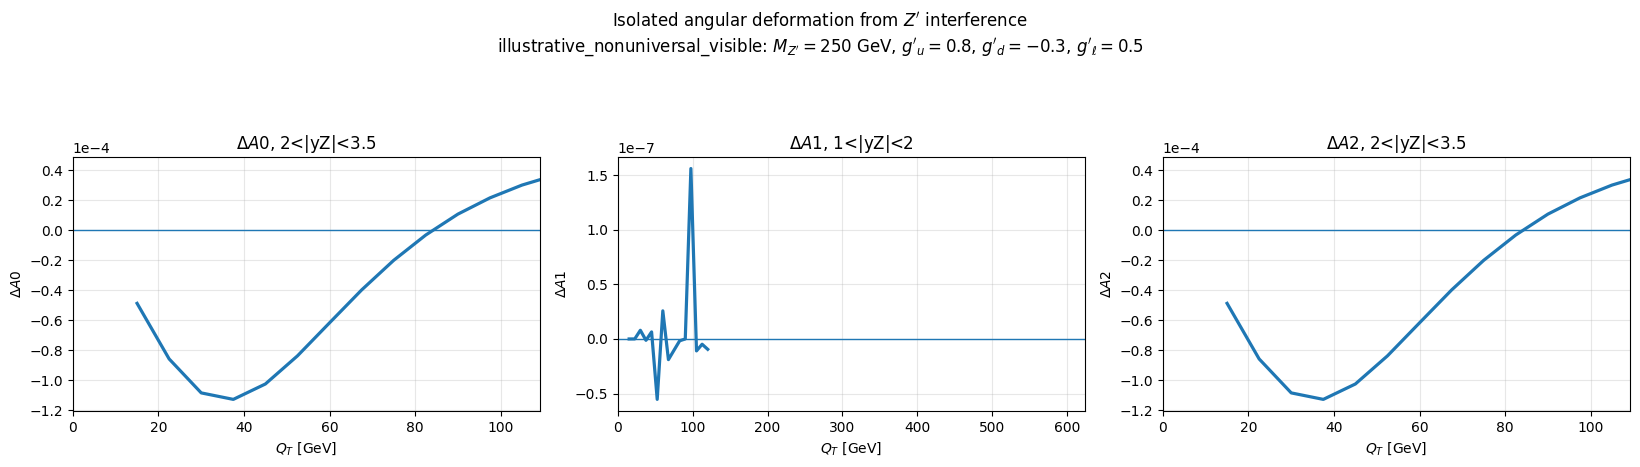

Saved: DY_Zprime_outputs/A012_delta_heavy_universal_almost_cancels.png


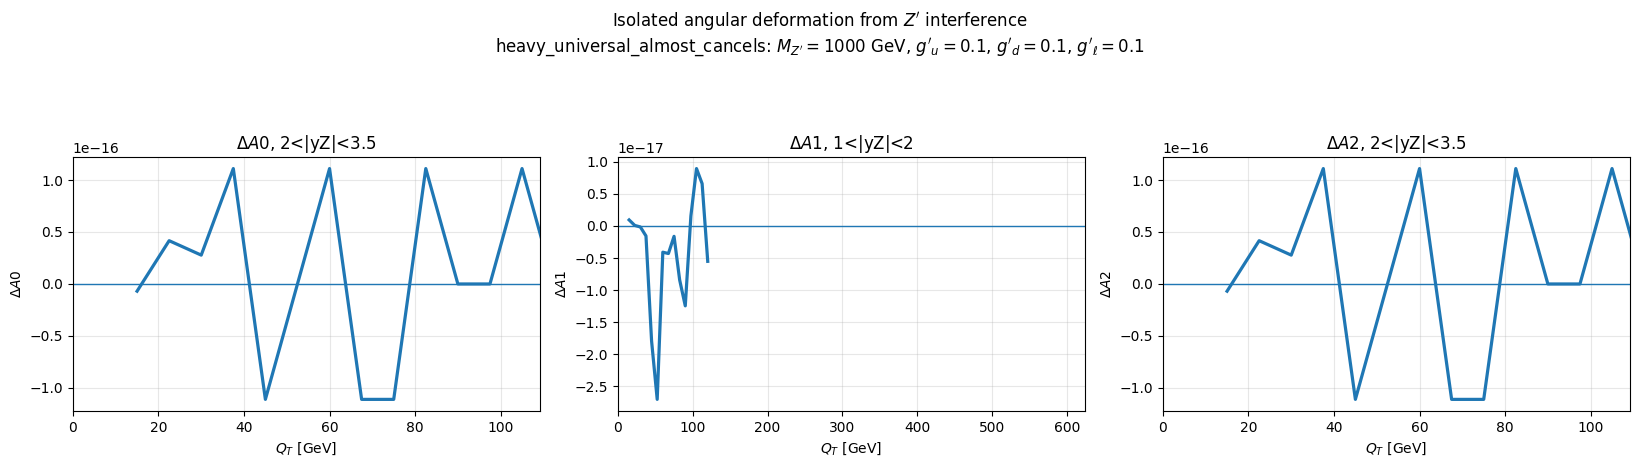

Saved: DY_Zprime_outputs/A012_delta_heavy_nonuniversal_test.png


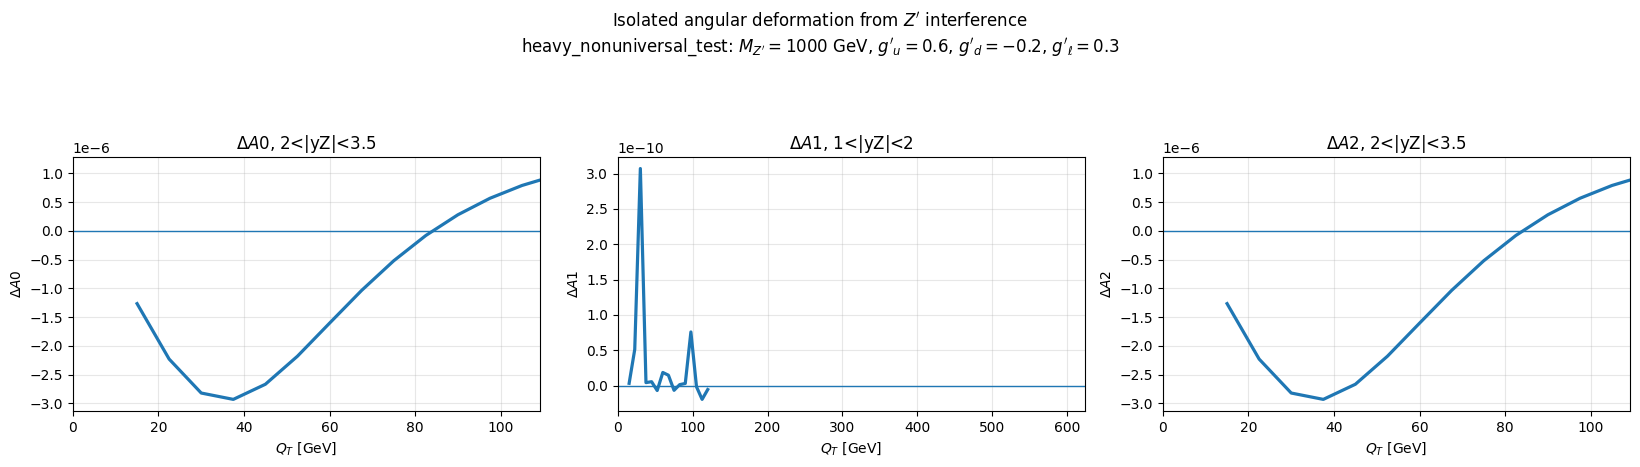

Saved: DY_Zprime_outputs/A012_delta_custom.png


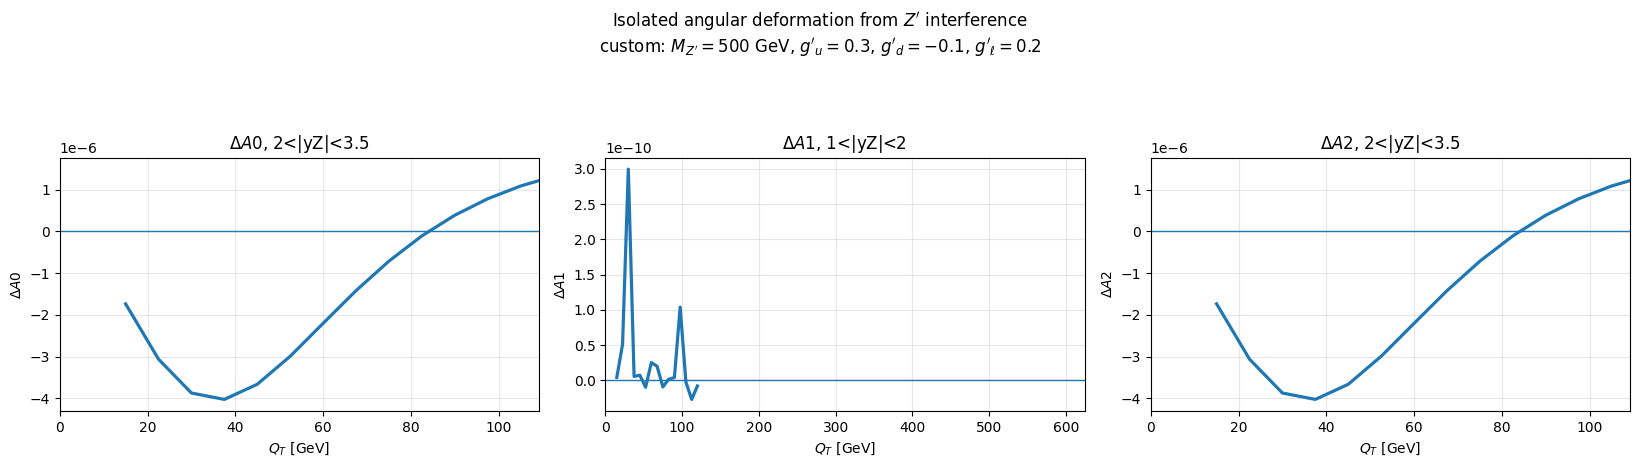


Size of the Z' shifts


,benchmark,coefficient,M_Zp_GeV,Gamma_Zp_GeV,gV_l,gV_u,gV_d,max_abs_delta,mean_abs_delta
0,illustrative_nonuniversal_visible,A0,250.0,10.0,0.5,0.8,-0.3,1.128440e-04,5.384301e-05
1,illustrative_nonuniversal_visible,A1,250.0,10.0,0.5,0.8,-0.3,1.559559e-07,2.057715e-08
2,illustrative_nonuniversal_visible,A2,250.0,10.0,0.5,0.8,-0.3,1.128440e-04,5.384301e-05
3,heavy_universal_almost_cancels,A0,1000.0,30.0,0.1,0.1,0.1,1.110223e-16,5.689893e-17
4,heavy_universal_almost_cancels,A1,1000.0,30.0,0.1,0.1,0.1,2.702564e-17,6.744778e-18
5,heavy_universal_almost_cancels,A2,1000.0,30.0,0.1,0.1,0.1,1.110223e-16,5.689893e-17
6,heavy_nonuniversal_test,A0,1000.0,30.0,0.3,0.6,-0.2,2.932858e-06,1.401850e-06
7,heavy_nonuniversal_test,A1,1000.0,30.0,0.3,0.6,-0.2,3.071115e-10,3.499218e-11
8,heavy_nonuniversal_test,A2,1000.0,30.0,0.3,0.6,-0.2,2.932858e-06,1.401850e-06
9,custom,A0,500.0,20.0,0.2,0.3,-0.1,4.025918e-06,1.923889e-06



Simple chi2 diagnostic


,coefficient,dataset,scenario,chi2,N,chi2_per_point
0,A0,"('A0', '2<|yZ|<3.5', 'regularised')",gamma,3.754739,14,0.268196
1,A0,"('A0', '2<|yZ|<3.5', 'regularised')",Zp::illustrative_nonuniversal_visible,3.746502,14,0.267607
2,A0,"('A0', '2<|yZ|<3.5', 'regularised')",Zp::heavy_universal_almost_cancels,3.754739,14,0.268196
3,A0,"('A0', '2<|yZ|<3.5', 'regularised')",Zp::heavy_nonuniversal_test,3.754524,14,0.268180
4,A0,"('A0', '2<|yZ|<3.5', 'regularised')",Zp::custom,3.754443,14,0.268175
5,A1,"('A1', '1<|yZ|<2', 'regularised')",gamma,1014.968773,15,67.664585
6,A1,"('A1', '1<|yZ|<2', 'regularised')",Zp::illustrative_nonuniversal_visible,1014.968700,15,67.664580
7,A1,"('A1', '1<|yZ|<2', 'regularised')",Zp::heavy_universal_almost_cancels,1014.968773,15,67.664585
8,A1,"('A1', '1<|yZ|<2', 'regularised')",Zp::heavy_nonuniversal_test,1014.968770,15,67.664585
9,A1,"('A1', '1<|yZ|<2', 'regularised')",Zp::custom,1014.968770,15,67.664585


Saved: DY_Zprime_outputs/individual_Zprime_shift_diagnostics.csv
Saved: DY_Zprime_outputs/individual_Zprime_chi2_diagnostics.csv


In [8]:

# ============================================================
# 5. Final diagnostic: individual Delta A_i plots and chi2
# ============================================================
# This cell should be run after the comparison cell above.
#
# It uses:
#     selected_zp_benchmarks
#     theory_by_scenario
#
# and produces:
#   1) one Delta A_i plot per selected benchmark;
#   2) a table with max and mean |Delta A_i|;
#   3) a simple chi2 table for data/theory comparison.

# ------------------------------------------------------------
# 5.1 Delta A_i plots
# ------------------------------------------------------------
def plot_single_benchmark_shift(benchmark_name, theory_by_scenario):
    """
    Produce one Delta A_i figure for one benchmark.

    Delta A_i is defined as:

        Delta A_i = A_i^(gamma + gamma Z') - A_i^gamma

    If this quantity is close to zero, the chosen benchmark does not produce
    a visible angular deformation in A0, A1 or A2.
    """
    scenario_key = f"Zp::{benchmark_name}"
    if scenario_key not in theory_by_scenario:
        raise KeyError(f"Missing computed theory for {scenario_key}")

    photon = theory_by_scenario["gamma"]
    zp_curve = theory_by_scenario[scenario_key]

    # Independent x-axes again.
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))

    for ax, coeff in zip(axes, ["A0", "A1", "A2"]):
        cfg = COMPARISON_CONFIG[coeff]
        key, df_exp = find_hepdata_dataset(
            data_by_key,
            coeff,
            cfg["data_ybin"],
            REGULARISATION,
        )

        delta = zp_curve[coeff] - photon[coeff]

        ax.plot(
            photon["QT"],
            delta,
            linewidth=2.3,
            label=rf"$\Delta {coeff}$",
        )
        ax.axhline(0.0, linewidth=1.0)

        x_min, x_max = get_data_x_limits(df_exp)
        ax.set_xlim(x_min, x_max)

        ax.set_title(rf"$\Delta {coeff}$, {cfg['data_ybin']}")
        ax.set_xlabel(r"$Q_T$ [GeV]")
        ax.set_ylabel(rf"$\Delta {coeff}$")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        r"Isolated angular deformation from $Z'$ interference"
        + "\n"
        + benchmark_label(benchmark_name),
        y=1.05,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if SAVE_FIGURES:
        safe_name = benchmark_name.replace(" ", "_").replace("/", "_")
        path = OUTDIR/f"A012_delta_{safe_name}.png"
        fig.savefig(path, dpi=220, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


for benchmark_name in selected_zp_benchmarks:
    plot_single_benchmark_shift(benchmark_name, theory_by_scenario)


# ------------------------------------------------------------
# 5.2 Simple numerical diagnostics
# ------------------------------------------------------------
def chi2_for_curve(theory_curve, coeff, df_exp):
    """
    Simple chi2 using interpolation of the theory curve to the experimental QT points.

    This is only a first diagnostic, not a final statistical limit.
    """
    qt_th = np.asarray(theory_curve["QT"], dtype=float)
    ai_th = np.asarray(theory_curve[coeff], dtype=float)

    qt_exp = np.asarray(df_exp["QT"], dtype=float)
    ai_exp = np.asarray(df_exp["Ai"], dtype=float)
    sigma = 0.5*(
        np.asarray(df_exp["err_plus"], dtype=float)
        + np.asarray(df_exp["err_minus"], dtype=float)
    )

    mask = (qt_exp >= qt_th.min()) & (qt_exp <= qt_th.max()) & (sigma > 0)

    if not np.any(mask):
        return np.nan, 0

    pred = np.interp(qt_exp[mask], qt_th, ai_th)
    chi2 = np.sum(((pred - ai_exp[mask])/sigma[mask])**2)

    return chi2, int(mask.sum())


def make_individual_shift_table(theory_by_scenario):
    """
    Return max and mean |Delta A_i| for every selected Z' benchmark.
    """
    rows = []
    photon = theory_by_scenario["gamma"]

    for benchmark_name in selected_zp_benchmarks:
        curve = theory_by_scenario[f"Zp::{benchmark_name}"]
        zp = ZPRIME_BENCHMARKS[benchmark_name]

        for coeff in ["A0", "A1", "A2"]:
            delta = curve[coeff] - photon[coeff]

            rows.append({
                "benchmark": benchmark_name,
                "coefficient": coeff,
                "M_Zp_GeV": zp["M"],
                "Gamma_Zp_GeV": zp["Gamma"],
                "gV_l": zp["gV_l"],
                "gV_u": zp["gV_u"],
                "gV_d": zp["gV_d"],
                "max_abs_delta": np.max(np.abs(delta)),
                "mean_abs_delta": np.mean(np.abs(delta)),
            })

    return pd.DataFrame(rows)


def make_individual_chi2_table(theory_by_scenario, data_by_key):
    """
    Return chi2 diagnostics for photon-only and each selected Z' benchmark.
    """
    rows = []

    for coeff, cfg in COMPARISON_CONFIG.items():
        key, df_exp = find_hepdata_dataset(
            data_by_key,
            coeff,
            cfg["data_ybin"],
            REGULARISATION,
        )

        if df_exp is None:
            rows.append({
                "coefficient": coeff,
                "dataset": "not found",
                "scenario": "-",
                "chi2": np.nan,
                "N": 0,
                "chi2_per_point": np.nan,
            })
            continue

        # Photon-only reference.
        chi2, n = chi2_for_curve(theory_by_scenario["gamma"], coeff, df_exp)
        rows.append({
            "coefficient": coeff,
            "dataset": str(key),
            "scenario": "gamma",
            "chi2": chi2,
            "N": n,
            "chi2_per_point": chi2/n if n else np.nan,
        })

        # One row for each selected benchmark.
        for benchmark_name in selected_zp_benchmarks:
            scenario_key = f"Zp::{benchmark_name}"
            chi2, n = chi2_for_curve(theory_by_scenario[scenario_key], coeff, df_exp)

            rows.append({
                "coefficient": coeff,
                "dataset": str(key),
                "scenario": scenario_key,
                "chi2": chi2,
                "N": n,
                "chi2_per_point": chi2/n if n else np.nan,
            })

    return pd.DataFrame(rows)


shift_df = make_individual_shift_table(theory_by_scenario)
print("\nSize of the Z' shifts")
display(shift_df)

chi2_df = make_individual_chi2_table(theory_by_scenario, data_by_key)
print("\nSimple chi2 diagnostic")
display(chi2_df)

if SAVE_FIGURES:
    shift_path = OUTDIR/"individual_Zprime_shift_diagnostics.csv"
    chi2_path = OUTDIR/"individual_Zprime_chi2_diagnostics.csv"

    shift_df.to_csv(shift_path, index=False)
    chi2_df.to_csv(chi2_path, index=False)

    print("Saved:", shift_path)
    print("Saved:", chi2_path)



## How to interpret the plots

The first plot answers:

> Does the theoretical prediction reproduce the real ATLAS/HEPData points?

The second plot answers:

> What angular deformation is produced by the chosen $Z'$ benchmark?

If

$$
\Delta A_i\simeq 0,
$$

then the chosen benchmark does not produce a visible signal in that angular coefficient.

If

$$
A_i^{\gamma+\gamma Z'}
$$

is closer to the data than

$$
A_i^\gamma,
$$

then that benchmark is more compatible with the data.

If the two curves overlap, the most common reasons are:

1. the $Z'$ is too heavy or too weakly coupled in the selected benchmark;
2. the benchmark gives nearly the same weight to all quark flavors;
3. the $Z'$ contribution acts mainly as a common normalization, which cancels in the ratios defining $A_i$.

For a visible test, use a non-universal benchmark with

$$
g'_u\neq g'_d.
$$



## Intentional limitations of this compact version

This notebook is reduced to the task described in the email.

It does not include:

- the small-$Q_T$ LP/NLP/NNLP expansion;
- diagnostic plots of $W_T$, $W_L$, $W_\Delta$ and $W_{\Delta\Delta}$;
- interactive widgets;
- the pure quadratic term $|\mathcal M_{Z'}|^2$;
- the angular coefficients $A_3,A_4,A_5,A_6,A_7$.

Extending the code to $A_3$ and $A_4$ requires implementing

$$
W_{\nabla P},
\qquad
W_{TP}.
$$

Extending it to $A_5$, $A_6$ and $A_7$ requires the T-odd structure functions, which are a different perturbative sector.
